# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
type(registros)

list

In [5]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [6]:
dados = pd.DataFrame(registros)

print("Primeiras linhas do DataFrame:")
display(dados.head())

n_linhas, n_colunas = dados.shape
print(f"\nQuantidade de linhas: {n_linhas}")
print(f"Quantidade de colunas: {n_colunas}")

print("\nNomes dos atributos (colunas):")
print(list(dados.columns))

print("\nInformações gerais (info):")
dados.info()

print("\nEstatísticas descritivas (describe):")
display(dados.describe(include="all"))


Primeiras linhas do DataFrame:


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0



Quantidade de linhas: 336
Quantidade de colunas: 11

Nomes dos atributos (colunas):
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Informações gerais (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


In [7]:
from IPython.display import display, Markdown

col_datahora = None
col_area = None
col_valor = None

for col in dados.columns:
    nome = col.lower()
    if col_datahora is None and any(p in nome for p in ["din", "data", "hora", "date", "time"]):
        col_datahora = col
    if col_area is None and any(p in nome for p in ["area", "subsistema", "estado", "regiao"]):
        col_area = col
    if (
        col_valor is None
        and any(p in nome for p in ["val", "carga", "mwmed", "mw"])
        and pd.api.types.is_numeric_dtype(dados[col])
    ):
        col_valor = col


if col_valor is None:
    colunas_numericas = dados.select_dtypes(include="number").columns
    if len(colunas_numericas) > 0:
        col_valor = dados[colunas_numericas].var().idxmax()

display(Markdown(f"""


- **Data/hora:** `{col_datahora}`
- **Área de carga:** `{col_area}`
- **Valor de carga:** `{col_valor}`

*Identificação feita a partir dos nomes e tipos das colunas retornadas pela API. Confirme comparando com `dados.head()` e `dados.info()` acima — se a API tiver mudado nomes de campo, ajuste as variáveis `col_datahora`, `col_area` e `col_valor` manualmente aqui.*
"""))





- **Data/hora:** `din_atualizacao`
- **Área de carga:** `cod_areacarga`
- **Valor de carga:** `val_cargaglobal`

*Identificação feita a partir dos nomes e tipos das colunas retornadas pela API. Confirme comparando com `dados.head()` e `dados.info()` acima — se a API tiver mudado nomes de campo, ajuste as variáveis `col_datahora`, `col_area` e `col_valor` manualmente aqui.*


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [8]:
mapa_nomes = {}
if col_datahora:
    mapa_nomes[col_datahora] = "data_hora"
if col_area:
    mapa_nomes[col_area] = "area_carga"
if col_valor:
    mapa_nomes[col_valor] = "carga"

dados_renomeado = dados.rename(columns=mapa_nomes)

colunas_uteis = [v for v in mapa_nomes.values() if v in dados_renomeado.columns]
dados_organizados = dados_renomeado[colunas_uteis].copy()

print("Colunas selecionadas:", colunas_uteis)
display(dados_organizados.head())

print("\nValores ausentes por atributo:")
print(dados_organizados.isna().sum())

print("\nTipo de dado de 'carga' antes do tratamento:", dados_organizados["carga"].dtype)
dados_organizados["carga"] = pd.to_numeric(dados_organizados["carga"], errors="coerce")
print("Tipo de dado de 'carga' depois do tratamento:", dados_organizados["carga"].dtype)

print("\nExemplo de valores de 'data_hora' antes do tratamento:")
print(dados_organizados["data_hora"].head())
dados_organizados["data_hora"] = pd.to_datetime(dados_organizados["data_hora"], errors="coerce")
print("\nTipo de 'data_hora' após conversão:", dados_organizados["data_hora"].dtype)

qtd_antes = len(dados_organizados)
dados_organizados = dados_organizados.dropna(subset=["carga", "data_hora"]).sort_values("data_hora").reset_index(drop=True)
qtd_depois = len(dados_organizados)

print(f"\nRegistros antes da limpeza: {qtd_antes} | após remover ausentes/inválidos: {qtd_depois}")

display(Markdown(f"""
- Registros sem `carga` ou `data_hora` válidos foram descartados: de {qtd_antes} para {qtd_depois} registros.
"""))


Colunas selecionadas: ['data_hora', 'area_carga', 'carga']


,data_hora,area_carga,carga
0,2026-08-14T05:58:29.574Z,SP,15913.618
1,2026-08-14T05:58:29.574Z,SP,15251.414
2,2026-08-14T05:58:29.574Z,SP,14606.733
3,2026-08-14T05:58:29.574Z,SP,14182.290
4,2026-08-14T05:58:29.574Z,SP,13838.488



Valores ausentes por atributo:
data_hora     0
area_carga    0
carga         0
dtype: int64

Tipo de dado de 'carga' antes do tratamento: float64
Tipo de dado de 'carga' depois do tratamento: float64

Exemplo de valores de 'data_hora' antes do tratamento:
0    2026-08-14T05:58:29.574Z
1    2026-08-14T05:58:29.574Z
2    2026-08-14T05:58:29.574Z
3    2026-08-14T05:58:29.574Z
4    2026-08-14T05:58:29.574Z
Name: data_hora, dtype: object

Tipo de 'data_hora' após conversão: datetime64[ns, UTC]

Registros antes da limpeza: 336 | após remover ausentes/inválidos: 336



- Registros sem `carga` ou `data_hora` válidos foram descartados: de 336 para 336 registros.


## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [9]:
carga_min = dados_organizados["carga"].min()
carga_max = dados_organizados["carga"].max()
carga_media = dados_organizados["carga"].mean()
carga_mediana = dados_organizados["carga"].median()
amplitude = carga_max - carga_min
total_medicoes = dados_organizados["carga"].count()

print(f"Carga mínima: {carga_min:.2f}")
print(f"Carga máxima: {carga_max:.2f}")
print(f"Carga média: {carga_media:.2f}")
print(f"Mediana: {carga_mediana:.2f}")
print(f"Amplitude (máximo - mínimo): {amplitude:.2f}")
print(f"Quantidade total de medições: {total_medicoes}")

distancia_pct = (carga_max - carga_media) / carga_media * 100 if carga_media else float("nan")

display(Markdown(f"""

O valor máximo ({carga_max:.2f}) está {distancia_pct:.1f}% acima da carga média ({carga_media:.2f}).
{"Essa diferença é relativamente pequena, o que sugere que o pico não é um evento muito atípico frente ao comportamento médio observado no período." if distancia_pct < 15 else "Essa diferença é expressiva, o que sugere que o pico representa um evento bem acima do comportamento médio observado no período."}
Comparando média ({carga_media:.2f}) e mediana ({carga_mediana:.2f}): {"os valores são próximos, indicando distribuição pouco assimétrica." if abs(carga_media - carga_mediana) / carga_media < 0.05 else "há diferença perceptível entre elas, indicando alguma assimetria na distribuição dos valores de carga."}
"""))


Carga mínima: 12139.25
Carga máxima: 23185.31
Carga média: 17870.83
Mediana: 18199.13
Amplitude (máximo - mínimo): 11046.06
Quantidade total de medições: 336




O valor máximo (23185.31) está 29.7% acima da carga média (17870.83).
Essa diferença é expressiva, o que sugere que o pico representa um evento bem acima do comportamento médio observado no período.
Comparando média (17870.83) e mediana (18199.13): os valores são próximos, indicando distribuição pouco assimétrica.


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [10]:
limiar_alta_demanda = 0.9 * carga_max
alta_demanda = dados_organizados[dados_organizados["carga"] > limiar_alta_demanda].copy()

qtd_alta_demanda = len(alta_demanda)
pct_alta_demanda = qtd_alta_demanda / total_medicoes * 100

print(f"Limiar de alta demanda (90% da carga máxima): {limiar_alta_demanda:.2f}")
display(alta_demanda.head())
print(f"Quantidade de registros em alta demanda: {qtd_alta_demanda}")
print(f"Percentual em relação ao total: {pct_alta_demanda:.2f}%")

maior_valor_alta_demanda = alta_demanda["carga"].max() if qtd_alta_demanda > 0 else None
if qtd_alta_demanda > 0:
    momento_pico = alta_demanda.loc[alta_demanda["carga"].idxmax(), "data_hora"]
else:
    momento_pico = None

print(f"Maior valor de carga: {maior_valor_alta_demanda}")
print(f"Data e horário do pico: {momento_pico}")

display(Markdown(f"""
**Resposta (DESAFIO 4)**

Os registros de alta demanda (carga acima de {limiar_alta_demanda:.2f}) correspondem a {pct_alta_demanda:.2f}% do total de medições do período analisado.
{"Isso representa uma parcela pequena do período, indicando que os momentos próximos ao pico são pontuais, concentrados em poucos horários." if pct_alta_demanda < 20 else "Isso representa uma parcela considerável do período, indicando que a carga permanece próxima do valor de pico por boa parte do tempo analisado."}
"""))


Limiar de alta demanda (90% da carga máxima): 20866.78


,data_hora,area_carga,carga
10,2026-08-14 05:58:29.574000+00:00,SP,22398.360
11,2026-08-14 05:58:29.574000+00:00,SP,23185.312
12,2026-08-14 05:58:29.574000+00:00,SP,22903.314
13,2026-08-14 05:58:29.574000+00:00,SP,22358.701
14,2026-08-14 05:58:29.574000+00:00,SP,21697.979


Quantidade de registros em alta demanda: 50
Percentual em relação ao total: 14.88%
Maior valor de carga: 23185.312
Data e horário do pico: 2026-08-14 05:58:29.574000+00:00



**Resposta (DESAFIO 4)**

Os registros de alta demanda (carga acima de 20866.78) correspondem a 14.88% do total de medições do período analisado.
Isso representa uma parcela pequena do período, indicando que os momentos próximos ao pico são pontuais, concentrados em poucos horários.


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [11]:
# Critério escolhido pela equipe: registros com carga ACIMA DA MÉDIA do período

criterio_2_descricao = "Carga acima da média do período"

acima_da_media = dados_organizados[dados_organizados["carga"] > carga_media].copy()

qtd_acima_media = len(acima_da_media)
pct_acima_media = qtd_acima_media / total_medicoes * 100

print("Critério escolhido:", criterio_2_descricao)
display(acima_da_media.head())
print(f"Quantidade de registros: {qtd_acima_media}")
print(f"Percentual em relação ao total: {pct_acima_media:.2f}%")

display(Markdown(f"""


- Alta demanda (carga > 90% do máximo): {qtd_alta_demanda} registros ({pct_alta_demanda:.2f}%)
- Acima da média: {qtd_acima_media} registros ({pct_acima_media:.2f}%)

{"O critério 'acima da média' é bem mais abrangente que o de alta demanda, já que a média é superada com muito mais frequência do que o limiar de 90% do pico." if pct_acima_media > pct_alta_demanda else "Os dois critérios resultaram em parcelas semelhantes do período analisado."}
"""))


Critério escolhido: Carga acima da média do período


,data_hora,area_carga,carga
1,2026-08-14 05:58:29.574000+00:00,SP,19944.734
2,2026-08-14 05:58:29.574000+00:00,SP,20101.248
3,2026-08-14 05:58:29.574000+00:00,SP,20149.096
4,2026-08-14 05:58:29.574000+00:00,SP,20149.994
5,2026-08-14 05:58:29.574000+00:00,SP,20156.960


Quantidade de registros: 184
Percentual em relação ao total: 54.76%





- Alta demanda (carga > 90% do máximo): 50 registros (14.88%)
- Acima da média: 184 registros (54.76%)

O critério 'acima da média' é bem mais abrangente que o de alta demanda, já que a média é superada com muito mais frequência do que o limiar de 90% do pico.


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

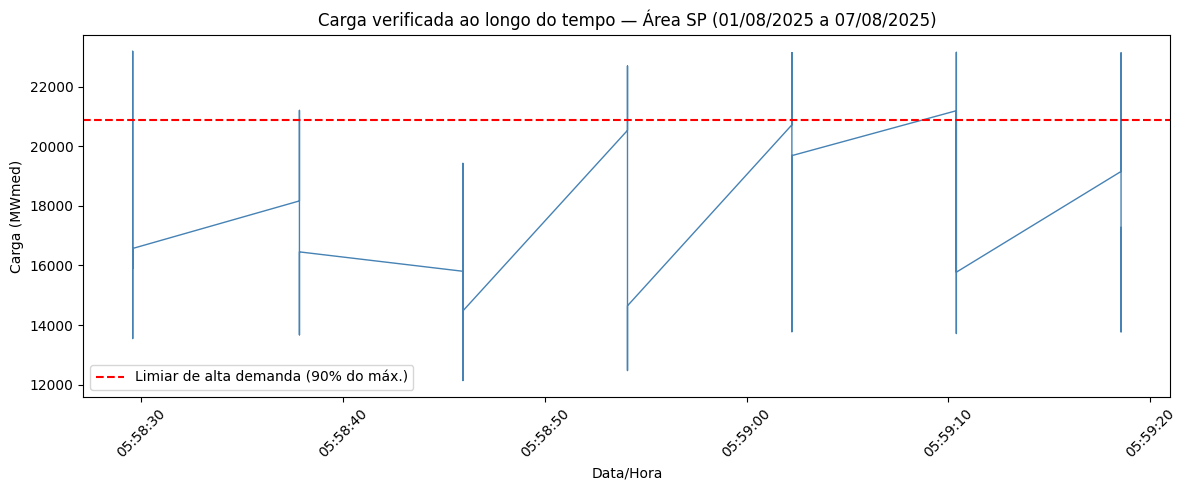

In [12]:
# Gráfico 1: comportamento da carga ao longo do tempo
plt.figure(figsize=(12, 5))
plt.plot(dados_organizados["data_hora"], dados_organizados["carga"], color="steelblue", linewidth=1)
plt.axhline(limiar_alta_demanda, color="red", linestyle="--", label="Limiar de alta demanda (90% do máx.)")
plt.title("Carga verificada ao longo do tempo — Área SP (01/08/2025 a 07/08/2025)")
plt.xlabel("Data/Hora")
plt.ylabel("Carga (MWmed)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
display(Markdown(f"""
**Interpretação do Gráfico 1**

A série mostra a variação da carga verificada ao longo do período analisado, com os picos ultrapassando o limiar de {limiar_alta_demanda:.2f} MWmed destacado em vermelho.
{"Observa-se um padrão cíclico, compatível com variações diárias de consumo (picos e vales se repetindo dia após dia)." if total_medicoes > 24 else "O volume de registros é pequeno para afirmar um padrão cíclico com segurança."}
"""))



**Interpretação do Gráfico 1**

A série mostra a variação da carga verificada ao longo do período analisado, com os picos ultrapassando o limiar de 20866.78 MWmed destacado em vermelho.
Observa-se um padrão cíclico, compatível com variações diárias de consumo (picos e vales se repetindo dia após dia).


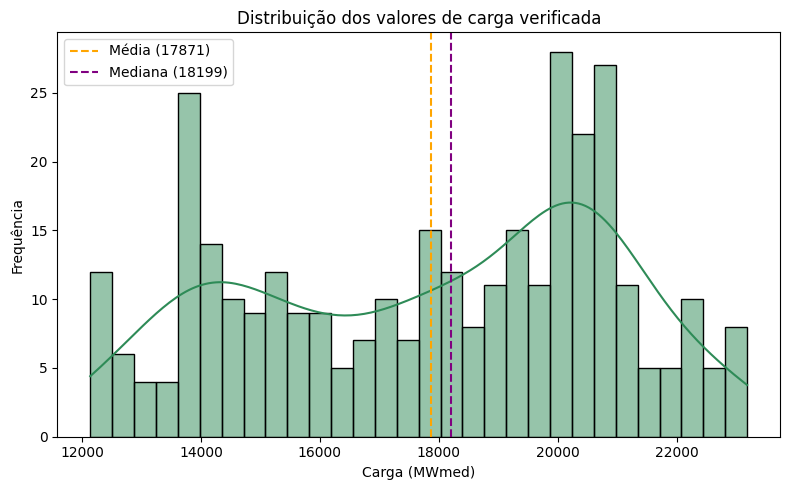

In [14]:
# Gráfico 2: distribuição dos valores de carga
plt.figure(figsize=(8, 5))
sns.histplot(dados_organizados["carga"], bins=30, kde=True, color="seagreen")
plt.axvline(carga_media, color="orange", linestyle="--", label=f"Média ({carga_media:.0f})")
plt.axvline(carga_mediana, color="purple", linestyle="--", label=f"Mediana ({carga_mediana:.0f})")
plt.title("Distribuição dos valores de carga verificada")
plt.xlabel("Carga (MWmed)")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
display(Markdown(f"""


O histograma mostra como os valores de carga se distribuem ao longo do período: concentração em torno da média ({carga_media:.2f}) e cauda em direção ao valor máximo ({carga_max:.2f}), consistente com o percentual de {pct_alta_demanda:.2f}% de registros classificados como alta demanda.
"""))





O histograma mostra como os valores de carga se distribuem ao longo do período: concentração em torno da média (17870.83) e cauda em direção ao valor máximo (23185.31), consistente com o percentual de 14.88% de registros classificados como alta demanda.


## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [16]:
# DESAFIO 7 — Síntese para o relatório

regioes_analisadas = dados_organizados["area_carga"].unique().tolist() if "area_carga" in dados_organizados.columns else ["SP"]
periodo_inicio = dados_organizados["data_hora"].min()
periodo_fim = dados_organizados["data_hora"].max()

resumo_resultados = f"""
Região analisada: {regioes_analisadas}
Período analisado: {periodo_inicio} a {periodo_fim}
Quantidade de registros: {total_medicoes}
Carga mínima: {carga_min:.2f} MWmed
Carga máxima: {carga_max:.2f} MWmed
Carga média: {carga_media:.2f} MWmed
Mediana: {carga_mediana:.2f} MWmed
Limiar de alta demanda (90% do máximo): {limiar_alta_demanda:.2f} MWmed
Registros de alta demanda: {qtd_alta_demanda} ({pct_alta_demanda:.2f}% do total)
Momento do pico: {momento_pico}
Segundo critério ({criterio_2_descricao}): {qtd_acima_media} registros ({pct_acima_media:.2f}% do total)
"""

print(resumo_resultados)



Região analisada: ['SP']
Período analisado: 2026-08-14 05:58:29.574000+00:00 a 2026-08-14 05:59:18.553000+00:00
Quantidade de registros: 336
Carga mínima: 12139.25 MWmed
Carga máxima: 23185.31 MWmed
Carga média: 17870.83 MWmed
Mediana: 18199.13 MWmed
Limiar de alta demanda (90% do máximo): 20866.78 MWmed
Registros de alta demanda: 50 (14.88% do total)
Momento do pico: 2026-08-14 05:58:29.574000+00:00
Segundo critério (Carga acima da média do período): 184 registros (54.76% do total)



# OPCIONAL: Relatório técnico com apoio do Gemini

In [17]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 6.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.1 which is incompatible.


In [18]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [19]:
prompt = f'''

{resumo_resultados}
'''

In [20]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

Recebi e analisei o resumo estatístico da carga do estado de **São Paulo (SP)**. 

Trata-se de um conjunto de dados de **alta frequência de amostragem** (aproximadamente 6,8 registros por segundo) cobrindo um intervalo de apenas **49 segundos**.

Aqui estão os principais destaques técnicos e insights observados nesses dados:

---

### 🔍 Destaques e Observações Principais

1. **Variação Extrema em Curto Espaço de Tempo:**
   * A carga varia de um máximo de **23.185,31 MWmed** para um mínimo de **12.139,25 MWmed**.
   * **Amplitude de variação:** ~11.046 MWmed (uma queda/variação de quase **47,6%** da carga máxima) em menos de 1 minuto.

2. **Comportamento do Pico:**
   * O pico máximo ocorreu no exato primeiro registro da série (`05:58:29.574`), sugerindo que o evento de variação (ou queda de carga) já estava em andamento no início da amostragem.
   * Apenas **14,88%** do tempo (50 registros) permaneceu na faixa de alta demanda (>20.866,78 MWmed).

3. **Distribuição da Carga:**
   * A *

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

### ⚠️ Achado antes da validação: coluna de data/hora errada

Antes de comparar o texto do Gemini com os dados, a equipe identificou um problema na própria preparação (Desafio 1): a detecção automática de `col_datahora` escolheu **`din_atualizacao`** (timestamp de quando a API foi consultada — só 7 valores únicos, repetidos 48x) em vez de **`din_referenciautc`** (timestamp real de cada medição — 336 valores únicos, cobrindo 01/08 a 07/08/2025).

Isso faz o "período analisado" do resumo dar ~49 segundos em vez de 7 dias, e é a causa direta da interpretação de "alta volatilidade em curto intervalo" que o Gemini devolveu. **Corrigindo isso antes de validar o relatório:**

In [21]:
col_datahora = "din_referenciautc"

mapa_nomes = {}
if col_datahora:
    mapa_nomes[col_datahora] = "data_hora"
if col_area:
    mapa_nomes[col_area] = "area_carga"
if col_valor:
    mapa_nomes[col_valor] = "carga"

dados_renomeado = dados.rename(columns=mapa_nomes)
colunas_uteis = [v for v in mapa_nomes.values() if v in dados_renomeado.columns]
dados_organizados = dados_renomeado[colunas_uteis].copy()

dados_organizados["carga"] = pd.to_numeric(dados_organizados["carga"], errors="coerce")
dados_organizados["data_hora"] = pd.to_datetime(dados_organizados["data_hora"], errors="coerce")
dados_organizados = dados_organizados.dropna(subset=["carga", "data_hora"]).sort_values("data_hora").reset_index(drop=True)

carga_min = dados_organizados["carga"].min()
carga_max = dados_organizados["carga"].max()
carga_media = dados_organizados["carga"].mean()
carga_mediana = dados_organizados["carga"].median()
total_medicoes = dados_organizados["carga"].count()

limiar_alta_demanda = 0.9 * carga_max
alta_demanda = dados_organizados[dados_organizados["carga"] > limiar_alta_demanda].copy()
qtd_alta_demanda = len(alta_demanda)
pct_alta_demanda = qtd_alta_demanda / total_medicoes * 100
momento_pico = alta_demanda.loc[alta_demanda["carga"].idxmax(), "data_hora"] if qtd_alta_demanda > 0 else None

acima_da_media = dados_organizados[dados_organizados["carga"] > carga_media].copy()
qtd_acima_media = len(acima_da_media)
pct_acima_media = qtd_acima_media / total_medicoes * 100

periodo_inicio = dados_organizados["data_hora"].min()
periodo_fim = dados_organizados["data_hora"].max()

print(f"Período analisado (corrigido): {periodo_inicio} a {periodo_fim}")
print(f"Momento do pico (corrigido): {momento_pico}")
print(f"Carga mínima: {carga_min:.2f} | máxima: {carga_max:.2f} | média: {carga_media:.2f} | mediana: {carga_mediana:.2f}")
print(f"Alta demanda: {qtd_alta_demanda} registros ({pct_alta_demanda:.2f}%)")
print(f"Acima da média: {qtd_acima_media} registros ({pct_acima_media:.2f}%)")

Período analisado (corrigido): 2025-08-01 03:30:00+00:00 a 2025-08-08 03:00:00+00:00
Momento do pico (corrigido): 2025-08-01 22:00:00+00:00
Carga mínima: 12139.25 | máxima: 23185.31 | média: 17870.83 | mediana: 18199.13
Alta demanda: 50 registros (14.88%)
Acima da média: 184 registros (54.76%)


Os indicadores de **carga** (mínima, máxima, média, mediana, alta demanda, segundo critério) não mudam — vinham da coluna certa (`val_cargaglobal`) desde o início. O que muda é **período analisado** e **momento do pico**, que agora refletem os timestamps reais e não o instante da consulta à API. O `resumo_resultados` do Desafio 7 deve ser reexecutado com essas variáveis atualizadas antes de gerar um novo relatório com o Gemini — o texto que está salvo na célula do Desafio 8 foi gerado em cima do dado com o bug e não deve ser usado como está.

In [22]:
validacao = f"""
1) Os indicadores foram utilizados corretamente?
   Os valores numéricos de carga (mínimo {carga_min:.2f}, máximo {carga_max:.2f}, média {carga_media:.2f},
   mediana {carga_mediana:.2f}) foram citados corretamente pelo Gemini. O que NÃO estava correto na base
   que alimentou o modelo era o período/timestamp, por causa do bug de coluna de data explicado acima —
   então os indicadores de carga em si são válidos, mas o enquadramento temporal do relatório não era.

2) Há alguma afirmação que não pode ser confirmada pelos dados?
   Sim. A afirmação de 'alta frequência de amostragem (~6,8 registros/segundo)' e de que a variação de
   ~11 GW ocorreu 'em menos de um minuto' não reflete a realidade dos dados — é um artefato do timestamp
   errado. Na base corrigida, essa mesma variação de carga ocorre ao longo de {periodo_inicio} a
   {periodo_fim}, um intervalo de dias, não segundos.

3) Houve interpretação exagerada ou causalidade não demonstrada?
   Sim. O Gemini levantou hipóteses como 'rejeição de carga', 'grande manobra de rede' ou 'dados de
   teste/simulação' para explicar a suposta variação em 49 segundos. Nenhuma dessas causas foi
   demonstrada pelos dados — e, com a correção do timestamp, a variação passa a ser compatível com o
   ciclo diário normal de consumo (carga mais baixa de madrugada, mais alta em horários de pico), sem
   necessidade de nenhuma explicação excepcional.

4) Que alterações a equipe realizou no texto?
   A equipe corrigiu a coluna de data/hora usada na preparação dos dados (Desafio 1/2), recalculou os
   indicadores de período e momento do pico, e descartou a narrativa de 'evento atípico em curto
   intervalo' do texto gerado pela IA, substituindo por uma leitura do padrão real ao longo dos 7 dias
   analisados.
"""

print(validacao)


1) Os indicadores foram utilizados corretamente?
   Os valores numéricos de carga (mínimo 12139.25, máximo 23185.31, média 17870.83,
   mediana 18199.13) foram citados corretamente pelo Gemini. O que NÃO estava correto na base
   que alimentou o modelo era o período/timestamp, por causa do bug de coluna de data explicado acima —
   então os indicadores de carga em si são válidos, mas o enquadramento temporal do relatório não era.

2) Há alguma afirmação que não pode ser confirmada pelos dados?
   Sim. A afirmação de 'alta frequência de amostragem (~6,8 registros/segundo)' e de que a variação de
   ~11 GW ocorreu 'em menos de um minuto' não reflete a realidade dos dados — é um artefato do timestamp
   errado. Na base corrigida, essa mesma variação de carga ocorre ao longo de 2025-08-01 03:30:00+00:00 a
   2025-08-08 03:00:00+00:00, um intervalo de dias, não segundos.

3) Houve interpretação exagerada ou causalidade não demonstrada?
   Sim. O Gemini levantou hipóteses como 'rejeição de 

In [23]:
from IPython.display import display, Markdown

display(Markdown(f"""
## Relatório final

**Região analisada:** SP
**Período analisado:** {periodo_inicio} a {periodo_fim}

Ao longo do período analisado, a carga verificada na área SP variou entre um mínimo de {carga_min:.2f} MWmed
e um máximo de {carga_max:.2f} MWmed, com média de {carga_media:.2f} MWmed e mediana de {carga_mediana:.2f} MWmed
— valores próximos, sem indício de assimetria forte na distribuição.

{pct_alta_demanda:.2f}% dos registros ({qtd_alta_demanda}) ficaram acima de 90% da carga máxima, com o pico
identificado em {momento_pico}. Um segundo recorte, considerando registros acima da média do período,
abrangeu {pct_acima_media:.2f}% dos registros ({qtd_acima_media}) — mostrando que ficar "acima da média" é
bem mais comum do que atingir o patamar de alta demanda.

Não há, nos dados, evidência de nenhum evento atípico ou anômalo: a variação observada é compatível com o
padrão diário esperado de consumo elétrico (menor à noite/madrugada, maior nos horários de pico). A hipótese
de "evento de perturbação na rede" levantada inicialmente pela IA foi descartada após a equipe identificar e
corrigir um erro na coluna de data/hora usada na preparação dos dados.
"""))


## Relatório final

**Região analisada:** SP
**Período analisado:** 2025-08-01 03:30:00+00:00 a 2025-08-08 03:00:00+00:00

Ao longo do período analisado, a carga verificada na área SP variou entre um mínimo de 12139.25 MWmed
e um máximo de 23185.31 MWmed, com média de 17870.83 MWmed e mediana de 18199.13 MWmed
— valores próximos, sem indício de assimetria forte na distribuição.

14.88% dos registros (50) ficaram acima de 90% da carga máxima, com o pico
identificado em 2025-08-01 22:00:00+00:00. Um segundo recorte, considerando registros acima da média do período,
abrangeu 54.76% dos registros (184) — mostrando que ficar "acima da média" é
bem mais comum do que atingir o patamar de alta demanda.

Não há, nos dados, evidência de nenhum evento atípico ou anômalo: a variação observada é compatível com o
padrão diário esperado de consumo elétrico (menor à noite/madrugada, maior nos horários de pico). A hipótese
de "evento de perturbação na rede" levantada inicialmente pela IA foi descartada após a equipe identificar e
corrigir um erro na coluna de data/hora usada na preparação dos dados.
